In [1]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)


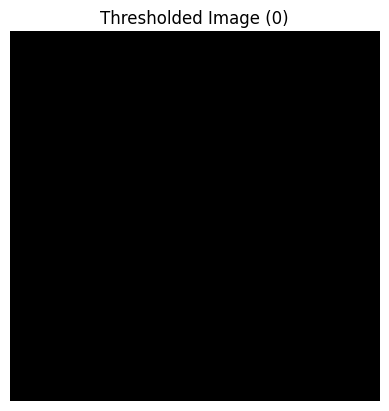

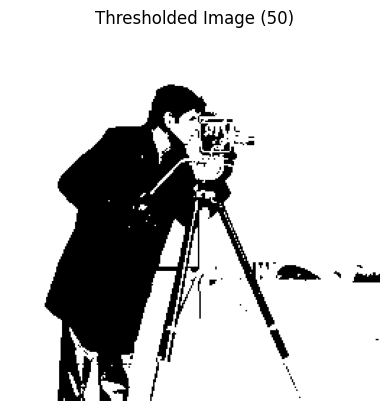

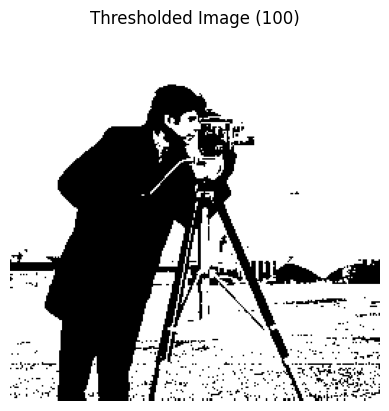

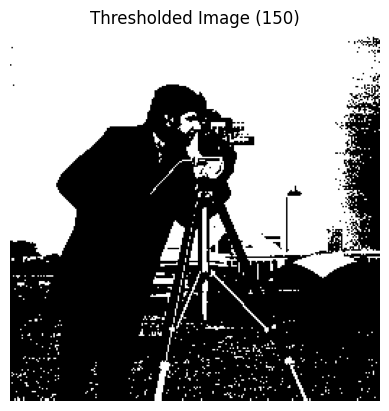

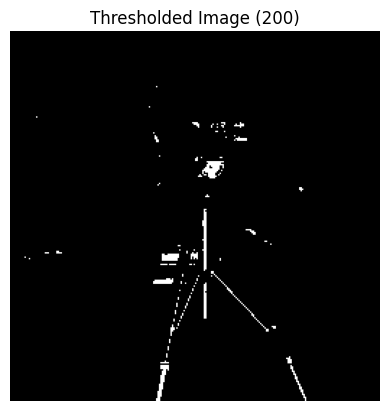

In [2]:
# Set the threshold values
import matplotlib.pyplot as plt

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    plt.imshow(thresh, cmap='gray')
    plt.title(f'Thresholded Image ({threshold_value})')
    plt.axis('off')
    plt.show()



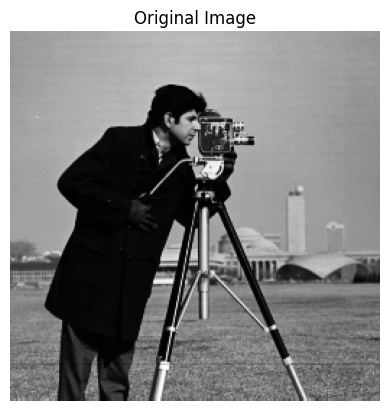

In [3]:
# Display the original image
import matplotlib.pyplot as plt

plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

In [4]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure

# Step#2: Load moon image
img = data.moon()


In [5]:
# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))


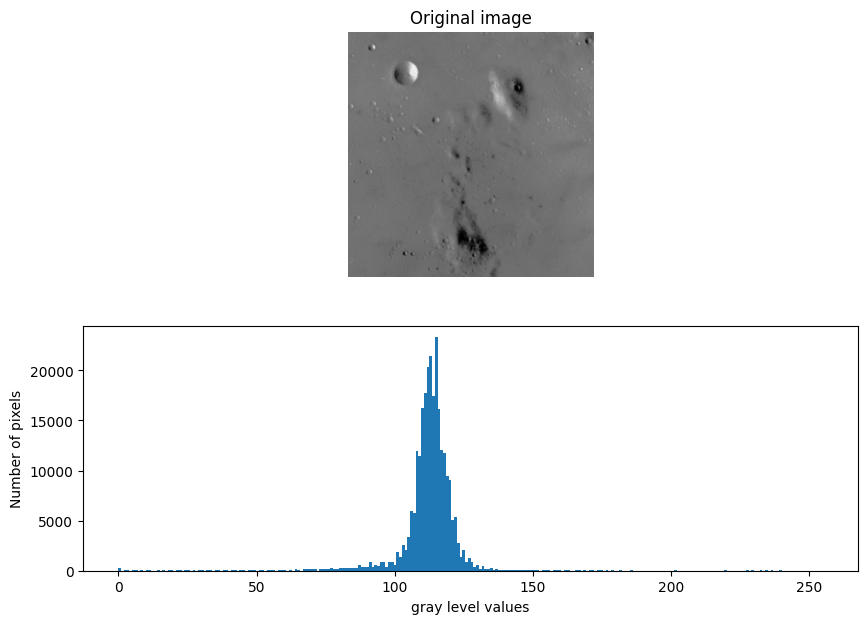

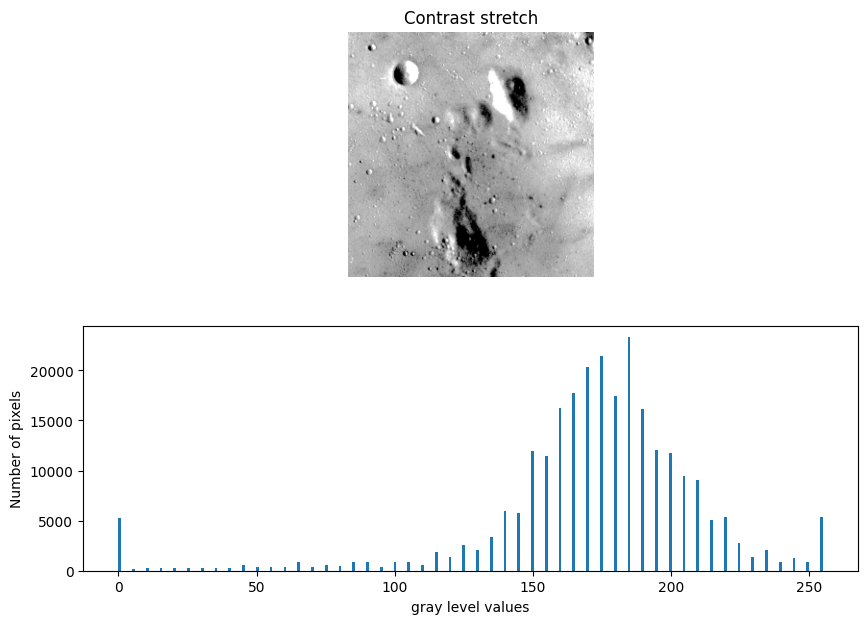

In [6]:
# Step#4: Display the image with its histogram of (step#2)  and (step#3)

fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img, cmap = 'gray') 
plt.axis('off') 
plt.title('Original image') 
fig.add_subplot(2, 1, 2) 
plt.hist(img.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 
fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img_rescale, cmap = 'gray') 
plt.axis('off') 
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2) 
plt.hist(img_rescale.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 

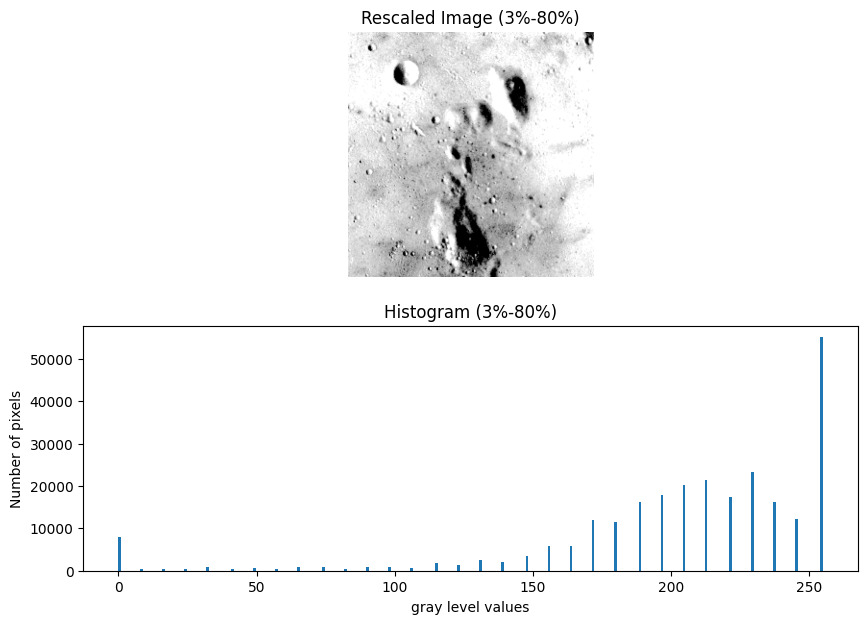

In [7]:
# Task 1: Rescale between 3% and 80%

p3, p80 = np.percentile(img, (3, 80))
img_rescale_2 = exposure.rescale_intensity(img, in_range=(p3, p80))

plt.figure(figsize=(10, 7))

plt.subplot(2,1,1)
plt.imshow(img_rescale_2, cmap='gray')
plt.title('Rescaled Image (3%-80%)')
plt.axis('off')

plt.subplot(2,1,2)
plt.hist(img_rescale_2.flat, bins=256, range=(0,255))
plt.title('Histogram (3%-80%)')
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')

plt.show()

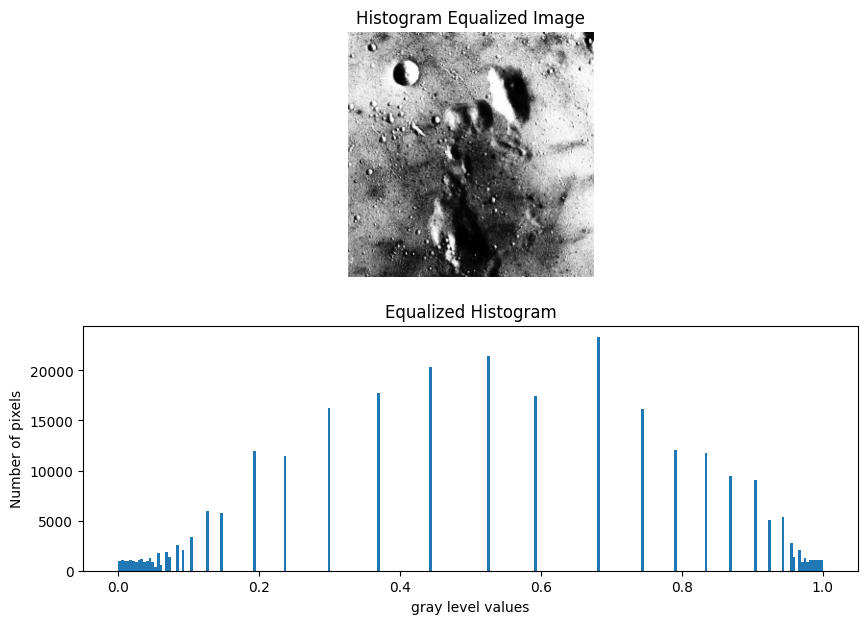

In [8]:
# Task 2: Histogram Equalization

img_equalized = exposure.equalize_hist(img)

plt.figure(figsize=(10, 7))

plt.subplot(2,1,1)
plt.imshow(img_equalized, cmap='gray')
plt.title('Histogram Equalized Image')
plt.axis('off')

plt.subplot(2,1,2)
plt.hist(img_equalized.flat, bins=256, range=(0,1))
plt.title('Equalized Histogram')
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')

plt.show()

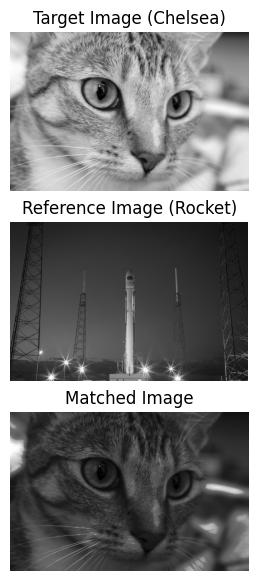

In [9]:
# Task 3: Histogram Matching

from skimage import data
from skimage.exposure import match_histograms

# Load images
reference = data.rocket()
target = data.chelsea()

# Convert to grayscale for consistency
import cv2
reference_gray = cv2.cvtColor(reference, cv2.COLOR_RGB2GRAY)
target_gray = cv2.cvtColor(target, cv2.COLOR_RGB2GRAY)

# Apply histogram matching
matched = match_histograms(target_gray, reference_gray)

# Display results
plt.figure(figsize=(10,7))

plt.subplot(3,1,1)
plt.imshow(target_gray, cmap='gray')
plt.title('Target Image (Chelsea)')
plt.axis('off')

plt.subplot(3,1,2)
plt.imshow(reference_gray, cmap='gray')
plt.title('Reference Image (Rocket)')
plt.axis('off')

plt.subplot(3,1,3)
plt.imshow(matched, cmap='gray')
plt.title('Matched Image')
plt.axis('off')

plt.show()